In [2]:
import torch
import torch.nn as nn
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.model_selection import train_test_split, KFold
import seaborn as sns
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### loading trained model

In [3]:
#load trained model
class AE(nn.Module):
    def __init__(self, input_size=103, latent_size=10):
        super(AE, self).__init__()
        self.input_size = input_size
        self.latent_size = latent_size

        # encoder network
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 56), nn.ReLU(),
            nn.Linear(56, 28), nn.ReLU(),
            nn.Linear(28, latent_size)
        )
        # decoder network
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 28), nn.ReLU(),
            nn.Linear(28, 56), nn.ReLU(),
            nn.Linear(56, input_size)
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

# def load_model(input_size, latent_size):
#     model = AE(input_size=input_size, latent_size=latent_size)
#     model.load_state_dict(
#         torch.load("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Autoencoder/best_autoencoder_nested_cv.pt")
#     )
#     model.eval()
#     return model
# model = load_model(103, 10)
# num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f"Trainable parameters: {num_trainable_params}")


# unbiased data

### data split:
- i first split the train_test_val dataset into 85% for training the autoencoder, 15% is set apart for PCA training.
- The PCA is then trained on this 15%, but evaluated on the unseen dataset
- for the SVM, i trained on 50% of the unseen dataset (the encoded latents) and evaluated on the other 50% of hte unseen dataset for seeing the classification performance

In [23]:
data = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data/A1_tr_te_val_dataset.csv")

#split the data for the autoencoder (85%) and for the PCA (15%)
df_ae, df_pca = train_test_split(data, train_size=0.85, stratify=data["Dataset"], random_state=42)

df_ae = df_ae.iloc[:,1:]
df_pca = df_pca.iloc[:,1:]
pd.set_option('display.max_columns', 500)


#splitting the training data from the tr_te_val_dataset such that we can have unbiased latents in the PCA to train on!
#df_pca.to_csv("PCA_training_data.csv")

#now we are going to remove the first few columns of the df_ae to make the model train!
df_ae = df_ae.iloc[:,5:]
df_ae

df_inner, df_outer = train_test_split(df_ae, train_size=0.85, random_state=42)

In [22]:

#######################
# Autoencoder Model
#######################
class AE(nn.Module):
    def __init__(self, input_size=103, latent_size=10):
        super(AE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_size, 56), nn.ReLU(),
            nn.Linear(56, 28), nn.ReLU(),
            nn.Linear(28, latent_size)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 28), nn.ReLU(),
            nn.Linear(28, 56), nn.ReLU(),
            nn.Linear(56, input_size)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


#######################
# training function   #
#######################
def train_ae(model, train_loader, val_loader, epochs, lr):
    loss_func = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # train
        model.train()
        train_loss = 0.0

        for x, in train_loader:
            optimizer.zero_grad()
            output = model(x)
            loss = loss_func(output, x)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, in val_loader:
                output = model(x)
                loss = loss_func(output, x)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    return train_losses, val_losses


#######################
# evaluation function #
#######################
def evaluate(model, dataloader):
    model.eval()
    all_outputs = []
    all_inputs = []

    with torch.no_grad():
        for x, in dataloader:
            output = model(x)
            all_outputs.append(output.numpy())
            all_inputs.append(x.numpy())

    all_outputs = np.concatenate(all_outputs, axis=0)
    all_inputs = np.concatenate(all_inputs, axis=0)

    mse = mean_squared_error(all_inputs, all_outputs)
    mae = mean_absolute_error(all_inputs, all_outputs)
    r2 = r2_score(all_inputs, all_outputs)

    return mse, mae, r2


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [20]:
def run_kfold(data_array, k=10, epochs=100, lr=0.01, batch_size=64):
    dataset = TensorDataset(torch.tensor(data_array, dtype=torch.float32))

    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    mse_scores, mae_scores, r2_scores = [], [], []

    best_model_state = None
    best_mse = float("inf")
    all_train_losses = []
    all_val_losses = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(data_array)):
        print(f"\n========== Fold {fold+1}/{k} ==========")

        # outer split
        X_train_full = data_array[train_idx]   # 85%
        X_val_outer = data_array[val_idx]      # 15% (true validation)

        # inner split 
        A1_1_1, A1_1_2 = train_test_split(X_train_full, test_size=0.176, random_state=42, shuffle=True)

        # scaling
        scaler = RobustScaler()
        A1_1_1 = scaler.fit_transform(A1_1_1)
        A1_1_2 = scaler.transform(A1_1_2)
        X_val_outer = scaler.transform(X_val_outer)

        # dataloaders
        train_loader = DataLoader(TensorDataset(torch.tensor(A1_1_1, dtype=torch.float32)),batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(TensorDataset(torch.tensor(A1_1_2, dtype=torch.float32)),batch_size=batch_size, shuffle=False)
        outer_val_loader = DataLoader(TensorDataset(torch.tensor(X_val_outer, dtype=torch.float32)),batch_size=batch_size, shuffle=False)
        
        model = AE(input_size=data_array.shape[1], latent_size=10)

        # train 
        train_losses, val_losses = train_ae(model, train_loader, val_loader, epochs, lr)

        all_train_losses.append(train_losses)
        all_val_losses.append(val_losses)

        # evaluate on outer fold
        mse, mae, r2 = evaluate(model, outer_val_loader)

        print(f"Fold {fold+1} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

        mse_scores.append(mse)
        mae_scores.append(mae)
        r2_scores.append(r2)

        # track best model
        if mse < best_mse:
            best_mse = mse
            best_model_state = model.state_dict()

    torch.save(best_model_state, "best_autoencoder.pt")

    print("\n========== Final Results ==========")
    print(f"MSE: {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
    print(f"MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
    print(f"R²:  {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")

    return mse_scores, mae_scores, r2_scores, all_train_losses, all_val_losses

data_array = df_ae.values

mse_scores, mae_scores, r2_scores, all_train_losses, all_val_losses = run_kfold(
    data_array,
    k=10,
    epochs=100,
    lr=0.01,
    batch_size=64 #should be 64 next run!
)


========== Fold 1/10 ==========
Epoch 1 | Train: 0.3438 | Val: 0.2946
Epoch 2 | Train: 0.2705 | Val: 0.2699
Epoch 3 | Train: 0.2536 | Val: 0.2481
Epoch 4 | Train: 0.2448 | Val: 0.2469
Epoch 5 | Train: 0.2398 | Val: 0.2385
Epoch 6 | Train: 0.2347 | Val: 0.2440
Epoch 7 | Train: 0.2289 | Val: 0.2451
Epoch 8 | Train: 0.2279 | Val: 0.2274
Epoch 9 | Train: 0.2296 | Val: 0.2252
Epoch 10 | Train: 0.2264 | Val: 0.2266
Epoch 11 | Train: 0.2269 | Val: 0.2269
Epoch 12 | Train: 0.2275 | Val: 0.2233
Epoch 13 | Train: 0.2248 | Val: 0.2225
Epoch 14 | Train: 0.2224 | Val: 0.2260
Epoch 15 | Train: 0.2348 | Val: 0.2386
Epoch 16 | Train: 0.2246 | Val: 0.2220
Epoch 17 | Train: 0.2240 | Val: 0.2232
Epoch 18 | Train: 0.2221 | Val: 0.2231
Epoch 19 | Train: 0.2267 | Val: 0.2265
Epoch 20 | Train: 0.2230 | Val: 0.2295
Epoch 21 | Train: 0.2244 | Val: 0.2240
Epoch 22 | Train: 0.2220 | Val: 0.2244
Epoch 23 | Train: 0.2133 | Val: 0.2136
Epoch 24 | Train: 0.2116 | Val: 0.2132
Epoch 25 | Train: 0.2114 | Val: 0.2131
E

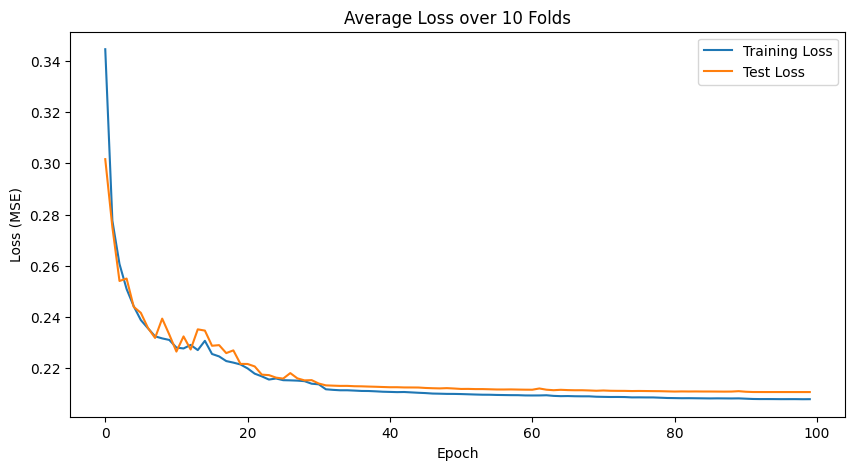

In [21]:
def plot_losses(train_losses, test_losses, title):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title(title)
    plt.legend()
    plt.show()

avg_train = np.mean(all_train_losses, axis=0)
avg_val = np.mean(all_val_losses, axis=0)

plot_losses(avg_train, avg_val, title="Average Loss over 10 Folds")


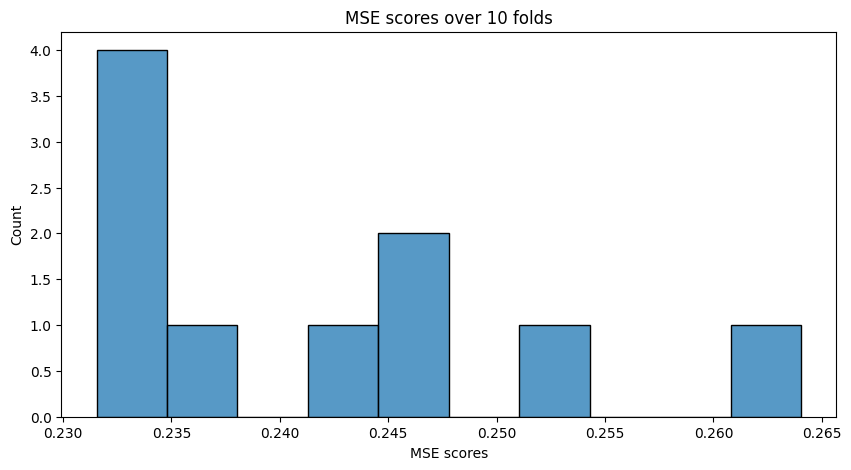

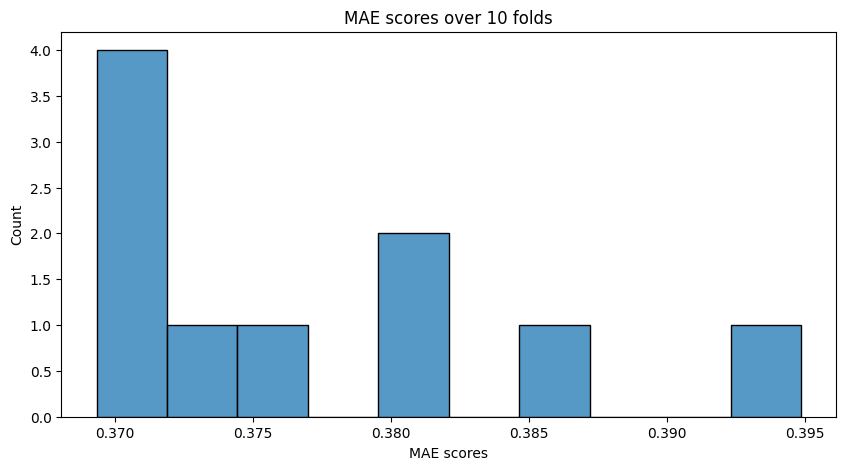

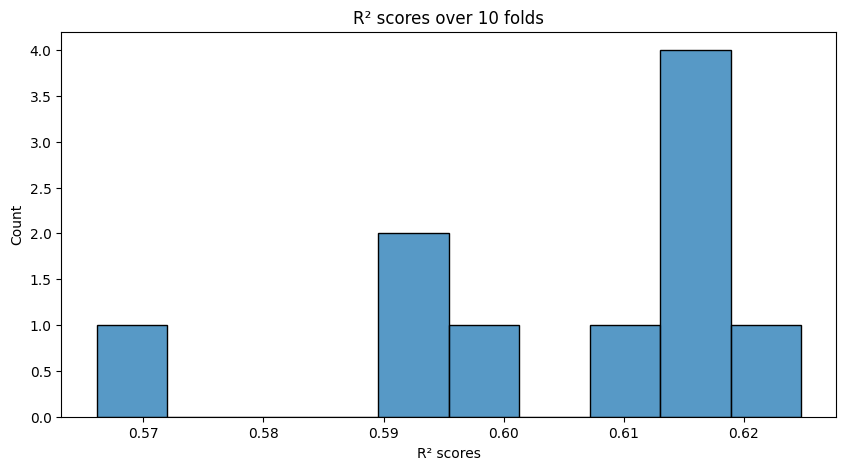

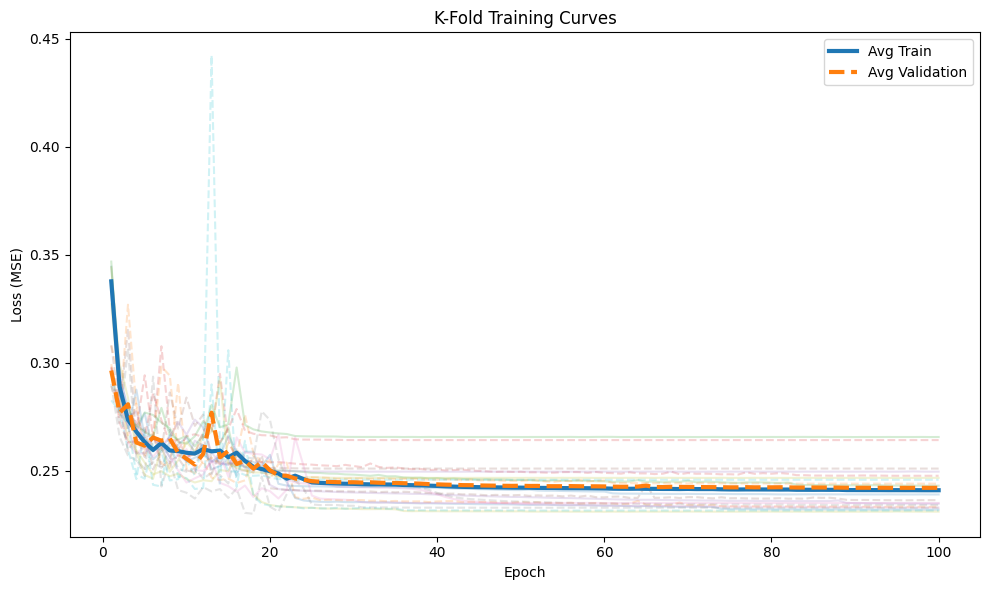

In [24]:
#mse
plt.figure(figsize=(10, 5))
sns.histplot(mse_scores, bins=10)
plt.xlabel('MSE scores')
plt.title("MSE scores over 10 folds")
plt.show()

#mae
plt.figure(figsize=(10, 5))
sns.histplot(mae_scores, bins=10)
plt.xlabel('MAE scores')
plt.title("MAE scores over 10 folds")
plt.show()

#r2
plt.figure(figsize=(10, 5))
sns.histplot(r2_scores, bins=10)
plt.xlabel('R² scores')
plt.title("R² scores over 10 folds")
plt.show()

def plot_kfold_losses(all_train_losses, all_val_losses):
    all_train_losses = np.array(all_train_losses)
    all_val_losses = np.array(all_val_losses)

    epochs = range(1, all_train_losses.shape[1] + 1)

    plt.figure(figsize=(10, 6))

    for i in range(len(all_train_losses)):
        plt.plot(epochs, all_train_losses[i], linestyle='-', alpha=0.2)
        plt.plot(epochs, all_val_losses[i], linestyle='--', alpha=0.2)
    avg_train = np.mean(all_train_losses, axis=0)
    avg_val = np.mean(all_val_losses, axis=0)

    plt.plot(epochs, avg_train, linewidth=3, label="Avg Train")
    plt.plot(epochs, avg_val, linewidth=3, linestyle='--', label="Avg Validation")

    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title("K-Fold Training Curves")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
avg_train = np.mean(all_train_losses, axis=0)
avg_val = np.mean(all_val_losses, axis=0)

plot_losses(avg_train, avg_val, title="Average Loss over 10 Folds")

for i in range(len(all_train_losses)):
    plot_losses(all_train_losses[i], all_val_losses[i], f"Average Loss for Fold {i +1}")
plot_kfold_losses(all_train_losses, all_val_losses)

In [5]:
data_array = df_ae.values

mse_scores, mae_scores, r2_scores, all_train_losses, all_val_losses = run_kfold(
    data_array,
    k=10,
    epochs=100,
    lr=0.01,
    batch_size=64 #should be 64 next run!
)


========== Fold 1/10 ==========
Epoch 1 | Train: 0.3351 | Val: 0.2904
Epoch 2 | Train: 0.2652 | Val: 0.2572
Epoch 3 | Train: 0.2507 | Val: 0.2500
Epoch 4 | Train: 0.2427 | Val: 0.2433
Epoch 5 | Train: 0.2373 | Val: 0.2360
Epoch 6 | Train: 0.2353 | Val: 0.2340
Epoch 7 | Train: 0.2353 | Val: 0.2349
Epoch 8 | Train: 0.2364 | Val: 0.2353
Epoch 9 | Train: 0.2369 | Val: 0.2326
Epoch 10 | Train: 0.2320 | Val: 0.2373
Epoch 11 | Train: 0.2325 | Val: 0.2289
Epoch 12 | Train: 0.2336 | Val: 0.2349
Epoch 13 | Train: 0.2340 | Val: 0.2318
Epoch 14 | Train: 0.2303 | Val: 0.2315
Epoch 15 | Train: 0.2339 | Val: 0.2299
Epoch 16 | Train: 0.2287 | Val: 0.2287
Epoch 17 | Train: 0.2291 | Val: 0.2285
Epoch 18 | Train: 0.2314 | Val: 0.2293
Epoch 19 | Train: 0.2299 | Val: 0.2306
Epoch 20 | Train: 0.2309 | Val: 0.2426
Epoch 21 | Train: 0.2373 | Val: 0.2267
Epoch 22 | Train: 0.2321 | Val: 0.2285
Epoch 23 | Train: 0.2310 | Val: 0.2254
Epoch 24 | Train: 0.2287 | Val: 0.2325
Epoch 25 | Train: 0.2306 | Val: 0.2270
E

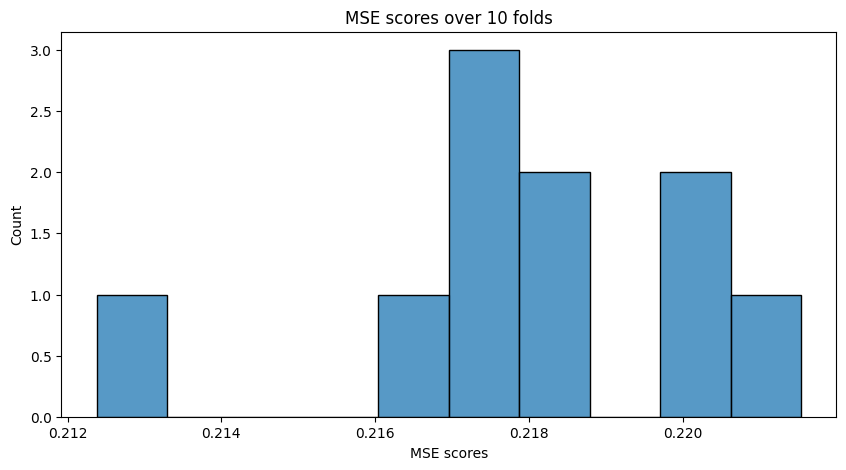

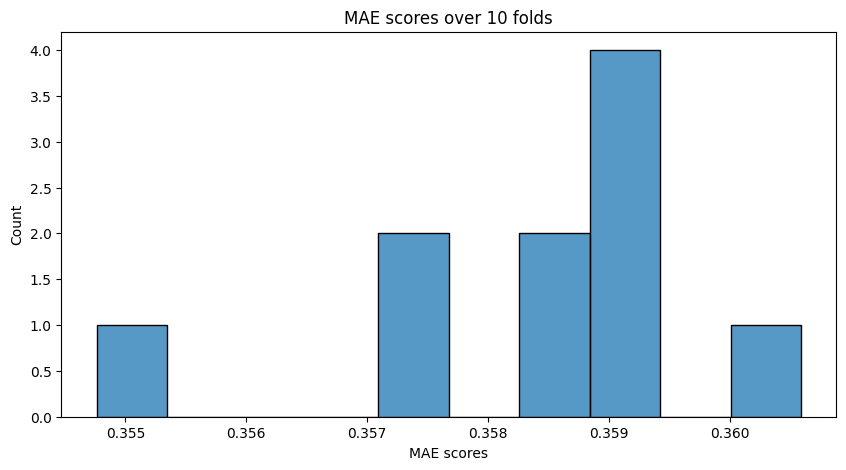

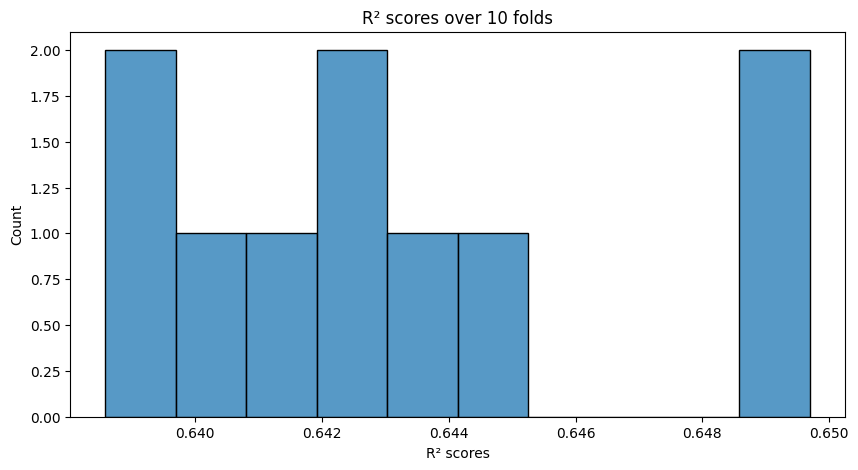

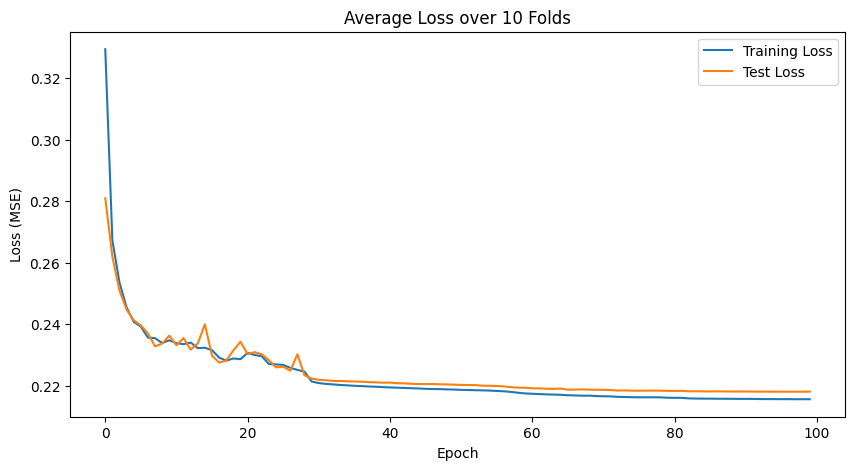

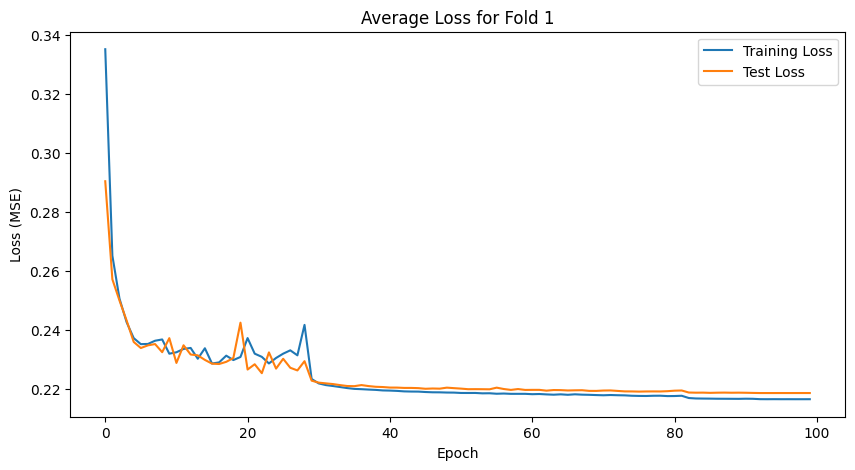

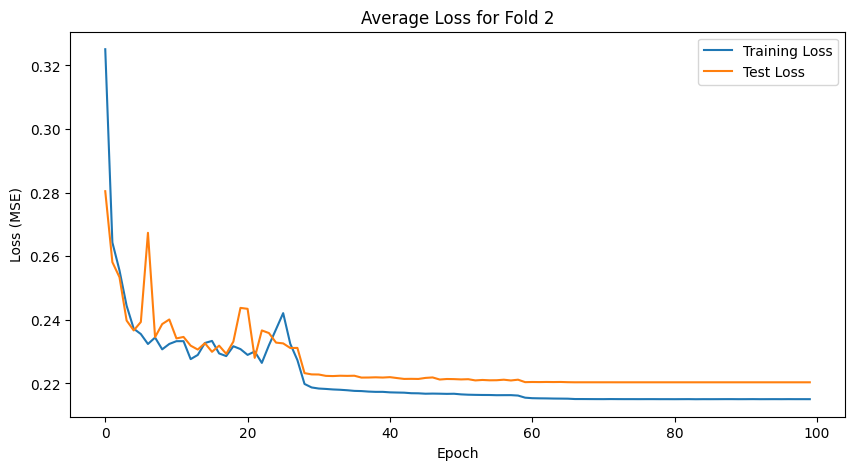

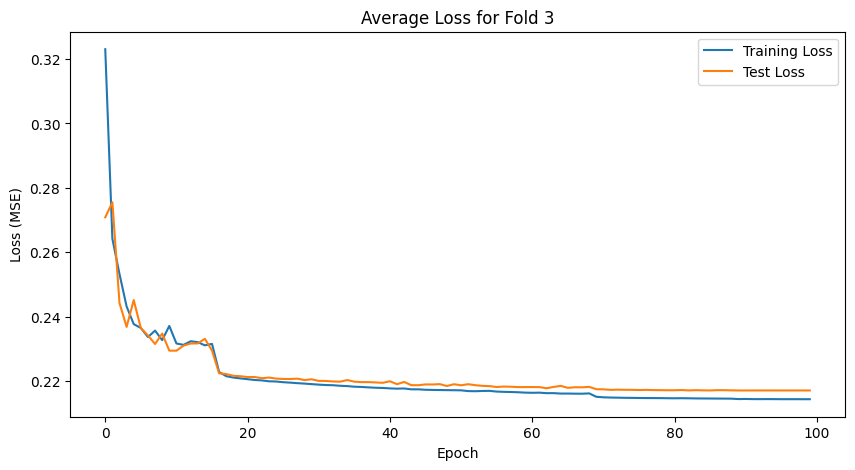

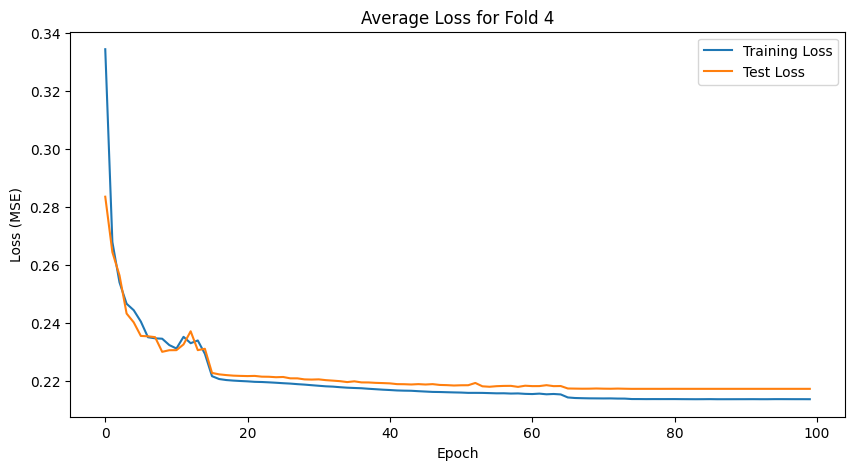

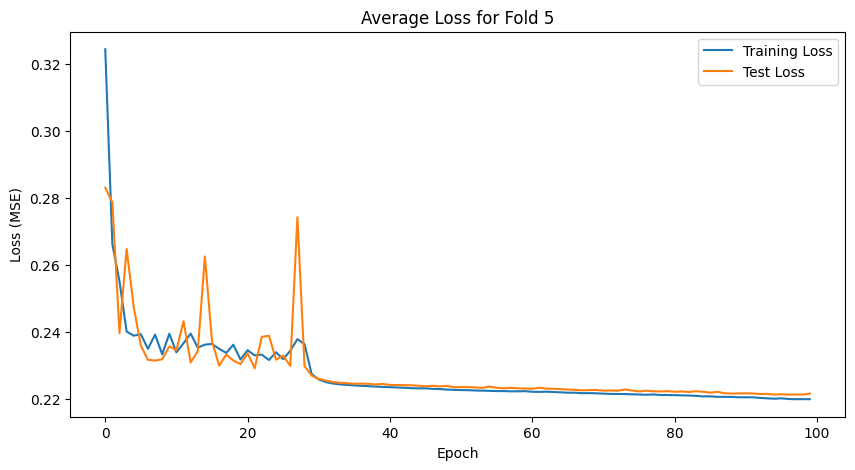

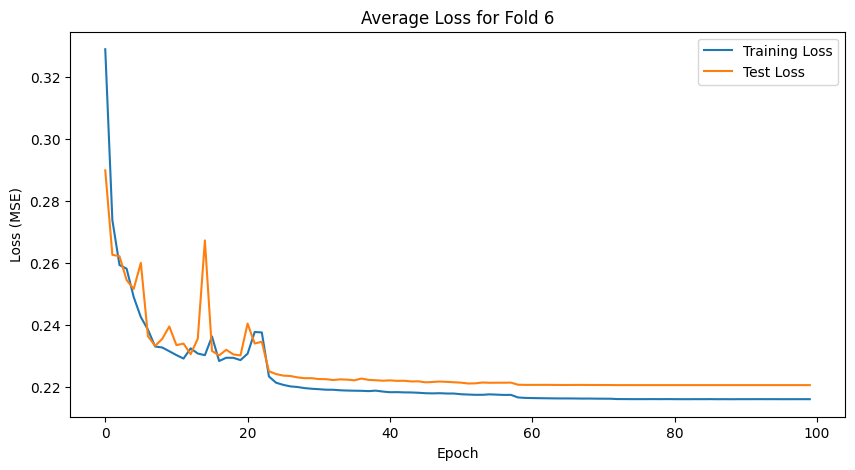

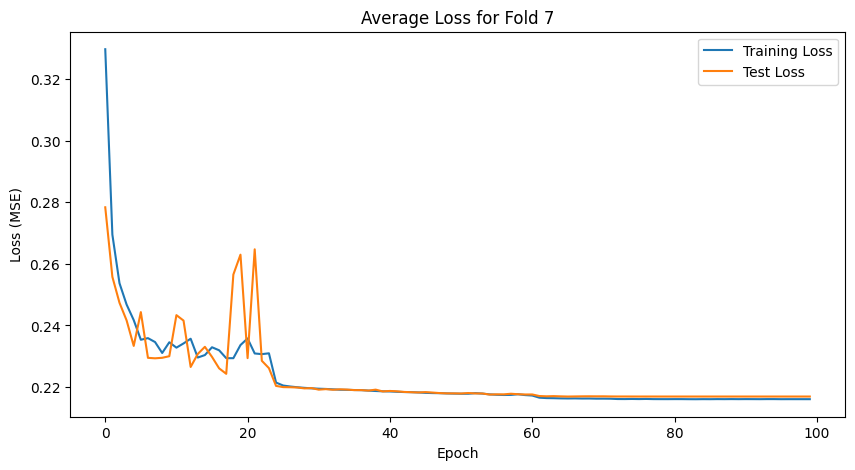

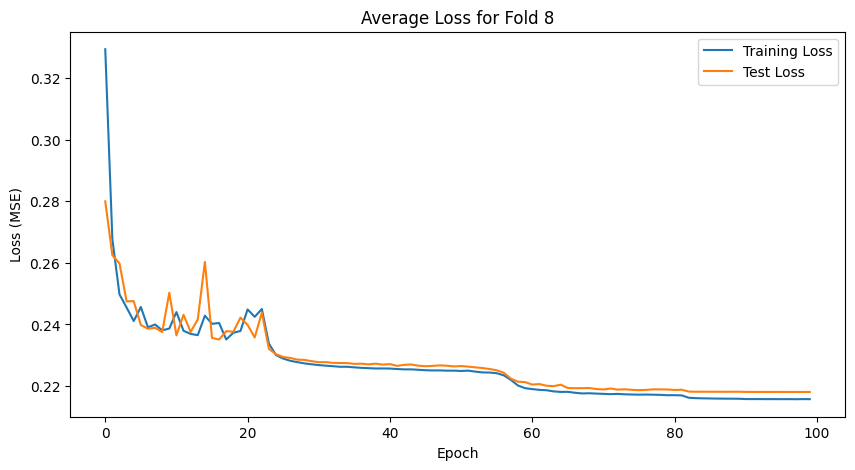

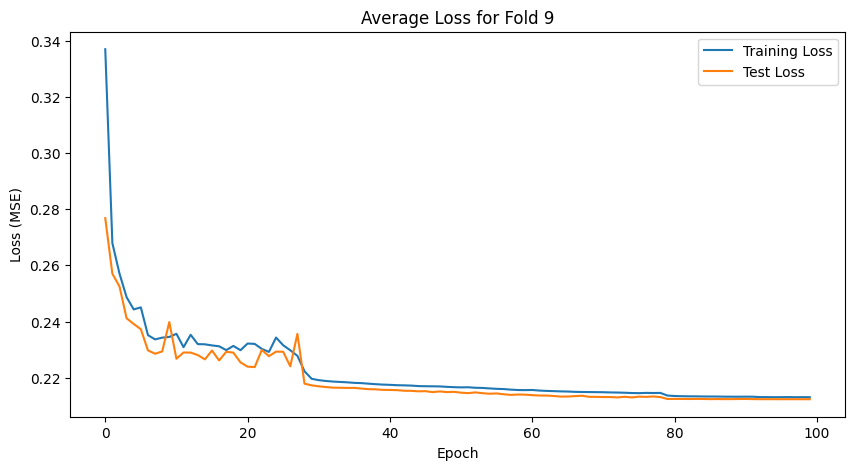

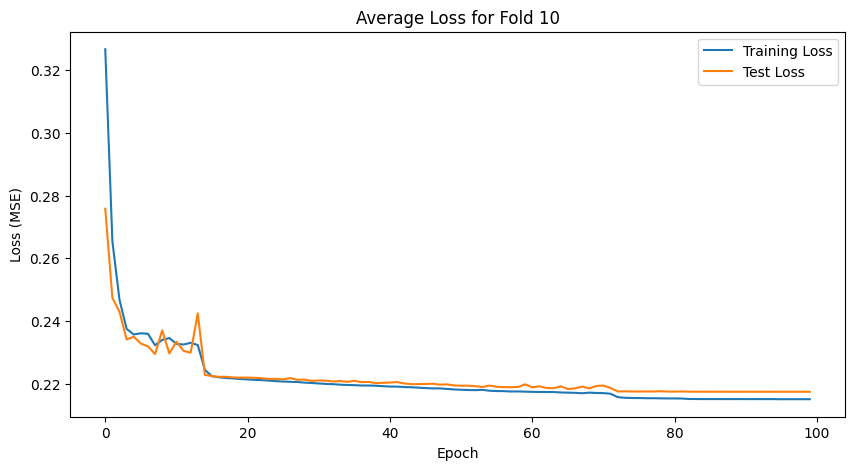

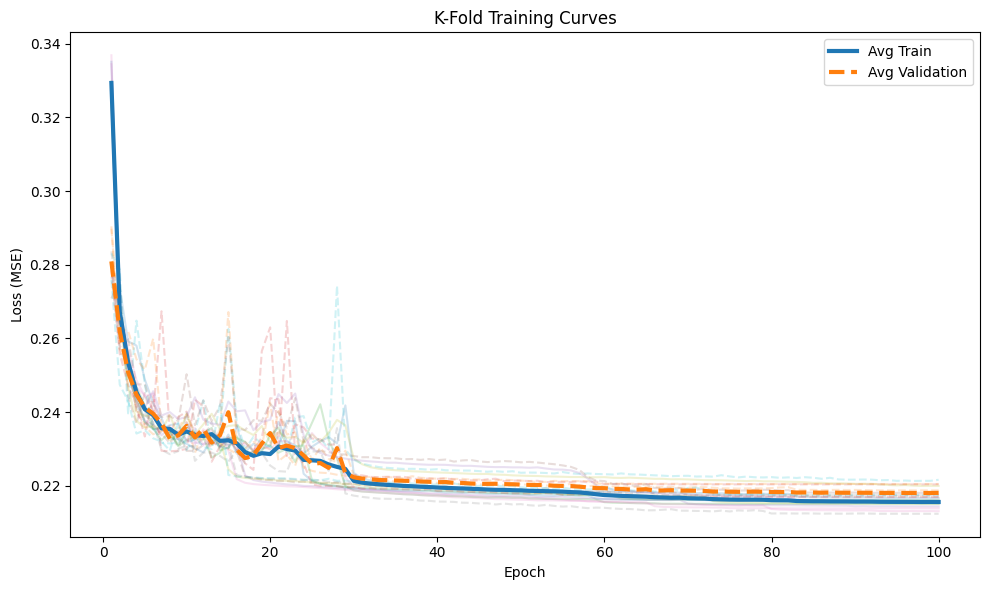

In [7]:
#mse
plt.figure(figsize=(10, 5))
sns.histplot(mse_scores, bins=10)
plt.xlabel('MSE scores')
plt.title("MSE scores over 10 folds")
plt.show()

#mae
plt.figure(figsize=(10, 5))
sns.histplot(mae_scores, bins=10)
plt.xlabel('MAE scores')
plt.title("MAE scores over 10 folds")
plt.show()

#r2
plt.figure(figsize=(10, 5))
sns.histplot(r2_scores, bins=10)
plt.xlabel('R² scores')
plt.title("R² scores over 10 folds")
plt.show()


avg_train = np.mean(all_train_losses, axis=0)
avg_val = np.mean(all_val_losses, axis=0)

plot_losses(avg_train, avg_val, title="Average Loss over 10 Folds")

for i in range(len(all_train_losses)):
    plot_losses(all_train_losses[i], all_val_losses[i], f"Average Loss for Fold {i +1}")
plot_kfold_losses(all_train_losses, all_val_losses)